# A seed that installs nothing but vocabulary

`10` ended on a negative result: the justification for supervising at all was that a policy
gradient cannot reweight an action that never appears in a sample, so a *minimal seed* should
hand the problem back to RL -- and two faithful implementations of that failed in opposite
directions. It also ended on a confound. Every seed in `10` was cut from `train.jsonl`, and a
seed drawn from the task's own training split cannot be told apart from supervised fine-tuning
on the task. "The seed only installed the vocabulary" stayed an assertion.

This notebook removes the confound and answers the question.

**The data.** 387 records generated to a brief and **never drawn from any split of the task**.
They are off-distribution by plant scale -- small municipal, large industrial and seawater
trains, at flows, conductivities, pressures, temperatures and recoveries outside every band the
four splits occupy, 0 of 387 inside any of them. The decision table reads percentage *changes*,
so it applies unchanged and the labels stay correct. **No label was supplied by the generator**:
every answer is derived locally with `task.generate.truth_from_record`, the same function that
grades every split, which makes a wrong label structurally impossible.

**The seed.** The loss is masked to the values of two slots, `root_cause` and `action` -- 10,752
supervised tokens. It never touches the arithmetic, the flags or the stage.

**The result.** The seeded policy reaches `exact_match` **0.255** on dev, and PPO takes it from
there to **0.930 on dev, 0.930 on the sealed test split and 0.920 on the distribution-shift
holdout** in 200 steps. The critic is ahead of a position-only clock on **100% of steps from
step 75 onward**.

**What this settles.** Supervision is worth +0.165 here (0.090 → 0.255) and PPO is worth
**+0.675** (0.255 → 0.930). `10` could not make that split because its seed taught the whole
task. Not one token of supervision in this run had a task answer as its target.

In [1]:
import json, sys
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

HERE = Path.cwd() if (Path.cwd() / "ppo_ac.py").exists() else Path("experiments/notebooks/smoke_test")
RUNS, DATA = HERE / "runs", HERE / "data"
sys.path.insert(0, str(HERE.resolve()))
sys.path.insert(0, str((HERE / ".." / ".." / "membrane_grpo").resolve()))
from task.decision_table import ACTION_SET, CAUSES, COVERED

def probe(name):
    d = json.load(open(RUNS / "probes" / f"{name}.json"))
    d["n_actions"] = len([k for k in d["action_hist"] if k in ACTION_SET])
    return d

def overall(name):
    return json.load(open(RUNS / "paired" / f"{name}.json"))["overall"]

seed_cases = [json.loads(l) for l in (DATA / "seed_cases.jsonl").read_text().splitlines() if l.strip()]
print(f"seed set: {len(seed_cases)} cases")

seed set: 387 cases


## The data, and what the first brief got wrong

Two rounds. The first asked for 300 records and **173 of them were unusable** -- a fault in the
brief, not in the generation. The decision table defines only 17 of the 72 possible
`(flow, salt_passage, dP, stage)` combinations, and the brief asked for cases "spread over the
other combinations" without saying which exist. The grader refuses to label the rest, so they
were thrown away. The second round listed the 17 rows explicitly and kept **260 of 260**.

That is worth recording rather than quietly fixing, because it is the whole cost of the one
thing this design does right: the generator never supplies a label, so a brief that produces
ungradeable records loses them loudly instead of producing plausible wrong answers silently.

In [2]:
by_source = Counter(c["source"] for c in seed_cases)
print(f"  the decision table defines {len(COVERED)} of 72 possible (flow, salt_passage, dP, stage) keys")
print()
for src, n_raw in (("seed_records_raw.jsonl", 300), ("seed_records_raw_round2.jsonl", 260)):
    print(f"  {src:34} kept {by_source.get(src, 0):>4} / {n_raw}")
print()
sev = [c for c in seed_cases if c["meta"]["severe"]]
og = [c for c in seed_cases if c["answer"]["root_cause"] == "organic_fouling"]
near_f = [c for c in seed_cases if -30 < c["meta"]["flow_pct"] <= -24]
near_s = [c for c in seed_cases if -15 < c["meta"]["sp_pct"] <= -9]
print(f"  severe (flow_pct <= -30)                {len(sev):>4}")
print(f"  organic_fouling                         {len(og):>4}")
print(f"  near-miss on flow severity  (-30, -24]  {len(near_f):>4}")
print(f"  near-miss on salt passage   (-15,  -9]  {len(near_s):>4}")
print(f"  cause coverage {len(set(c['answer']['root_cause'] for c in seed_cases))}/7"
      f"   action coverage {len(set(c['answer']['action'] for c in seed_cases))}/8")
print()
print("  off-distribution: records inside the bands train.jsonl occupies")
bands = {"permeate_flow_m3_h": (20, 60), "feed_conductivity_uS_cm": (2000, 6000),
         "feed_pressure_bar": (12, 20), "feed_temp_C": (20, 25)}
for f, (lo, hi) in bands.items():
    v = [c["record"]["t0"][f] for c in seed_cases]
    print(f"    {f:28} {sum(lo <= x <= hi for x in v):>3} / {len(v)}"
          f"      (range {min(v):.1f} - {max(v):.1f})")
v = [c["record"]["recovery_pct"] for c in seed_cases]
print(f"    {'recovery_pct':28} {sum(68 <= x <= 78 for x in v):>3} / {len(v)}"
      f"      (range {min(v):.1f} - {max(v):.1f})")

  the decision table defines 17 of 72 possible (flow, salt_passage, dP, stage) keys

  seed_records_raw.jsonl             kept  127 / 300
  seed_records_raw_round2.jsonl      kept  260 / 260

  severe (flow_pct <= -30)                  95
  organic_fouling                           89
  near-miss on flow severity  (-30, -24]    89
  near-miss on salt passage   (-15,  -9]    81
  cause coverage 7/7   action coverage 8/8

  off-distribution: records inside the bands train.jsonl occupies
    permeate_flow_m3_h             0 / 387      (range 2.8 - 398.1)
    feed_conductivity_uS_cm        0 / 387      (range 449.4 - 28131.0)
    feed_pressure_bar              0 / 387      (range 7.0 - 69.5)
    feed_temp_C                    0 / 387      (range 8.1 - 35.9)
    recovery_pct                   0 / 387      (range 35.0 - 89.9)


## The two ends of the axis, from frozen

`10` named `sft_dead_weight` as the axis between its two failures: how hard one member of a slot
is lifted while the slot keeps a distribution over the rest. Re-run from the frozen model on the
independent records, both ends fail the same way they did in `10`, which is the point -- the
failure was never about where the data came from.

In [3]:
print(f"  {'seed':26}{'severe emit':>16}{'organic emit':>16}{'actions used':>14}")
for name, label in (("frz-dead-only", "dead labels only"),
                    ("frz-slots-w1", "both slots, w=1"),
                    ("frz-slots-w4", "both slots, w=4"),
                    ("frz-slots-w8", "both slots, w=8")):
    p = probe(name)
    print(f"  {label:26}{p['severe_emitted']:>6}/{p['samples']:<4}{p['severe_emitted']/p['samples']:>5.1%}"
          f"{p['og_emitted']:>6}/{p['samples']:<4}{p['og_emitted']/p['samples']:>5.1%}"
          f"{p['n_actions']:>8} of 8")
print()
print(f"  for reference, the true rates in those 600 sampled slots:"
      f" severe {probe('frz-slots-w4')['severe_slots']/600:.1%},"
      f" organic {probe('frz-slots-w4')['og_slots']/600:.1%}")
print()
print("  Supervising the dead strings and nothing else does not seed the slots, it erases")
print("  them: one action in the whole vocabulary, organic at 73% against a true 13%.")
print("  With the slot's negatives restored the collapse is gone and severe lands on its")
print("  true rate -- and raising w from 1 to 8 does nothing for organic, which is the")
print("  measurement that says the axis was the wrong knob for it.")

  seed                           severe emit    organic emit  actions used
  dead labels only             600/600 100.0%   437/600 72.8%       1 of 8
  both slots, w=1              105/600 17.5%    14/600  2.3%       4 of 8
  both slots, w=4              108/600 18.0%     7/600  1.2%       6 of 8
  both slots, w=8              108/600 18.0%     7/600  1.2%       8 of 8

  for reference, the true rates in those 600 sampled slots: severe 18.0%, organic 13.3%

  Supervising the dead strings and nothing else does not seed the slots, it erases
  them: one action in the whole vocabulary, organic at 73% against a true 13%.
  With the slot's negatives restored the collapse is gone and severe lands on its
  true rate -- and raising w from 1 to 8 does nothing for organic, which is the
  measurement that says the axis was the wrong knob for it.


## Why the axis was the wrong knob

The two labels are not the same kind of object, and that is what the sweep was blind to.
`isolate_and_evaluate_replacement` is an **action**, set by a threshold on a number the policy
already reproduces exactly (`numeric_acc` is 1.000 everywhere). `organic_fouling` is a
**root_cause**, set by a flag combination -- and it is the only row in the table with
`salt_passage = "down"`.

So the seed can install the action outright, and cannot install the cause, because the cause
depends on a field the seed is not allowed to touch.

In [4]:
diag = json.load(open(RUNS / "action_diag_fixed_frz-slots-w4.json"))
og_cases = [r for r in diag if r["true_cause"] == "organic_fouling"]
sev_cases = [r for r in diag if r["severe"]]
print("  the w=4 seed, greedy on dev")
print(f"    severe action recall              {sum(r['pred_action'] == 'isolate_and_evaluate_replacement' for r in sev_cases)}/{len(sev_cases)}")
print(f"    organic_fouling recall            {sum(r['cause_ok'] for r in og_cases)}/{len(og_cases)}")
print()
print(f"    on those {len(og_cases)} organic cases:")
print(f"      salt_passage called correctly   "
      f"{sum(r['pred_flags']['salt_passage'] == r['true_flags']['salt_passage'] for r in og_cases)}/{len(og_cases)}"
      f"   <- the discriminating flag, read right every time")
print(f"      all three flags correct         {sum(r['flags_ok'] for r in og_cases)}/{len(og_cases)}"
      f"   <- but the other two are not")
print(f"      named instead                   {Counter(r['pred_cause'] for r in og_cases).most_common()}")
print()
print(f"    all three flags correct, whole split   {sum(r['flags_ok'] for r in diag)}/{len(diag)}")
print()
print("  The seed reads the one flag that identifies organic_fouling on every case and still")
print("  cannot name it, because its own stated evidence -- the other two flags -- does not")
print("  form the key. Reading flags is the thing the seed is forbidden to teach, and the")
print("  thing PPO demonstrably does teach.")

  the w=4 seed, greedy on dev
    severe action recall              37/37
    organic_fouling recall            0/29

    on those 29 organic cases:
      salt_passage called correctly   29/29   <- the discriminating flag, read right every time
      all three flags correct         0/29   <- but the other two are not
      named instead                   [('scaling', 16), ('biofouling', 13)]

    all three flags correct, whole split   53/200

  The seed reads the one flag that identifies organic_fouling on every case and still
  cannot name it, because its own stated evidence -- the other two flags -- does not
  form the key. Reading flags is the thing the seed is forbidden to teach, and the
  thing PPO demonstrably does teach.


## PPO from the seeded policy

200 steps, `resume_from` the w=4 seed, identical configuration to the `09`/`10` runs. Step 0
reproduces the seed exactly, so the continuation is genuinely continuing.

The gates were recalibrated before the run for a policy that starts at `flags_acc` 0.673 rather
than 0.977, and the critic's was deferred to step 50 because this run's value head starts at
initialisation -- seeding from frozen leaves no trained critic to inherit.

In [5]:
ev = [json.loads(l) for l in (RUNS / "ppo-on-seed-w4" / "eval.jsonl").read_text().splitlines() if l.strip()]
me = [json.loads(l) for l in (RUNS / "ppo-on-seed-w4" / "metrics.jsonl").read_text().splitlines() if l.strip()]

def critic_window(lo, hi):
    w = [m for m in me if lo <= m["step"] < hi and "value_ev" in m]
    d = [m["value_ev"] - m["value_ev_position"] for m in w]
    f = [m["value_ev_fit"] - m["value_ev_position_fit"] for m in w if "value_ev_fit" in m]
    return sum(d) / len(d), sum(x > 0 for x in d) / len(d), sum(f) / len(f)

base = ev[0]
print(f"  {'step':>5}{'exact':>9}{'flags':>9}{'cause':>8}{'action':>8}{'numeric':>9}   critic (25-step window)")
for r in ev:
    lo = max(0, r["step"] - 25)
    c = critic_window(lo, r["step"]) if r["step"] else None
    ctxt = f"   {c[0]:+.4f}  ahead {c[1]:>4.0%}  fit {c[2]:+.4f}" if c else "   (head at init)"
    print(f"  {r['step']:>5}{r['exact_match']:>9.3f}{r['flags_acc']:>9.4f}{r['cause_acc']:>8.3f}"
          f"{r['action_acc']:>8.3f}{r['numeric_acc']:>9.3f}{ctxt}")
print()
print("  exact_match falls at step 25 and that was accepted in advance: the gate that had to")
print("  hold every round was the critic's, not the task metric's. It crosses its null")
print("  baseline by step 25-49 and is ahead on every single step from 75 on, with the")
print("  in-sample fit tracking it -- the head fits the window it was trained on.")

   step    exact    flags   cause  action  numeric   critic (25-step window)
      0    0.255   0.6733   0.385   0.480    1.000   (head at init)
     25    0.170   0.6883   0.565   0.640    1.000   -0.0587  ahead  32%  fit -0.0139
     50    0.625   0.8833   0.875   0.895    1.000   +0.0032  ahead  64%  fit +0.0059
     75    0.690   0.9267   0.915   0.940    1.000   +0.0154  ahead  88%  fit +0.0170
    100    0.815   0.9433   0.935   0.950    1.000   +0.0195  ahead 100%  fit +0.0203
    125    0.855   0.9567   0.955   0.975    1.000   +0.0206  ahead 100%  fit +0.0211
    150    0.865   0.9567   0.940   0.960    1.000   +0.0200  ahead 100%  fit +0.0205
    175    0.885   0.9633   0.960   0.975    1.000   +0.0199  ahead 100%  fit +0.0202
    200    0.930   0.9767   0.955   0.965    1.000   +0.0223  ahead 100%  fit +0.0225

  exact_match falls at step 25 and that was accepted in advance: the gate that had to
  hold every round was the critic's, not the task metric's. It crosses its null


**The critic residual is small and that is the honest number.** Naive `value_ev` runs about
0.93 on this task, and a position-only clock -- a baseline that does nothing but count tokens --
gets about 0.92. The critic's own contribution is the ~0.02 difference, and quoting 0.93 would
be quoting the clock.

## Held out, on splits nothing selected on

In [6]:
rows = [("frozen (v3 prompt)", None, 0.090, "dev, from 09"),
        ("+ seed only", "frz-slots-w4_dev", None, "dev"),
        ("+ seed + PPO 200", "ppo_on_seed_test", None, "test"),
        ("+ seed + PPO 200", "ppo_on_seed_holdout_shift", None, "holdout_shift")]
print(f"  {'policy':24}{'split':>16}{'exact':>9}{'cause':>8}{'action':>8}{'flags':>8}{'c|flags':>9}")
for label, key, fallback, split in rows:
    if key is None:
        print(f"  {label:24}{split:>16}{fallback:>9.3f}")
        continue
    o = overall(key)
    print(f"  {label:24}{split:>16}{o['exact_match']:>9.3f}{o['cause_acc']:>8.3f}"
          f"{o['action_acc']:>8.3f}{o['flags_acc']:>8.3f}{o['cause_given_flags']:>9.3f}")
print()
t = overall("ppo_on_seed_test")
print(f"  dev {ev[-1]['exact_match']:.3f} / test {t['exact_match']:.3f} /"
      f" holdout_shift {overall('ppo_on_seed_holdout_shift')['exact_match']:.3f}"
      f"  -- the three agree, so nothing here is a selection artefact")
print(f"  causes emitted on test: {len([k for k in t['predicted_cause_hist'] if k in CAUSES])} of 7")
print(f"  cause_given_flags on test: {t['cause_given_flags']:.3f}")

  policy                             split    exact   cause  action   flags  c|flags
  frozen (v3 prompt)          dev, from 09    0.090
  + seed only                          dev    0.255   0.385   0.480   0.673    0.962
  + seed + PPO 200                    test    0.930   0.955   0.965   0.973    1.000
  + seed + PPO 200           holdout_shift    0.920   0.940   0.960   0.973    1.000

  dev 0.930 / test 0.930 / holdout_shift 0.920  -- the three agree, so nothing here is a selection artefact
  causes emitted on test: 7 of 7
  cause_given_flags on test: 1.000


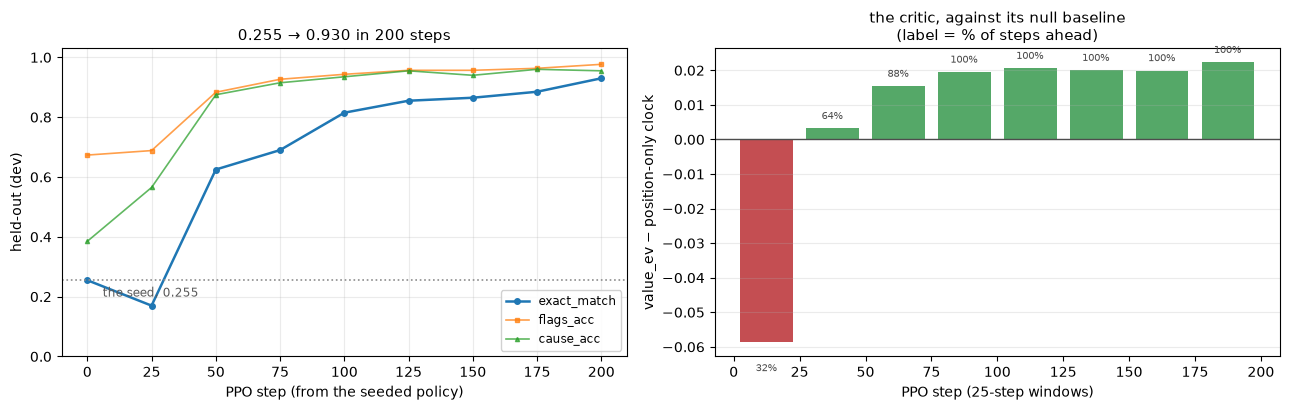

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))

steps = [r["step"] for r in ev]
ax1.plot(steps, [r["exact_match"] for r in ev], "o-", lw=1.8, ms=4, label="exact_match")
ax1.plot(steps, [r["flags_acc"] for r in ev], "s-", lw=1.2, ms=3, alpha=.75, label="flags_acc")
ax1.plot(steps, [r["cause_acc"] for r in ev], "^-", lw=1.2, ms=3, alpha=.75, label="cause_acc")
ax1.axhline(base["exact_match"], color="0.55", ls=":", lw=1.2)
ax1.text(6, base["exact_match"] - .055, f"the seed, {base['exact_match']:.3f}", color="0.35", fontsize=8.5)
ax1.set_xlabel("PPO step (from the seeded policy)"); ax1.set_ylabel("held-out (dev)")
ax1.set_ylim(0, 1.03); ax1.legend(fontsize=8.5, loc="lower right", framealpha=.9)
ax1.set_title("0.255 → 0.930 in 200 steps", fontsize=10.5); ax1.grid(alpha=.25)

edges = list(range(0, 201, 25))
xs = [(a + b) / 2 for a, b in zip(edges, edges[1:])]
res = [critic_window(a, b)[0] for a, b in zip(edges, edges[1:])]
ahead = [critic_window(a, b)[1] for a, b in zip(edges, edges[1:])]
bars = ax2.bar(xs, res, width=20, color=["#c44e52" if r <= 0 else "#55a868" for r in res])
for x, r, a in zip(xs, res, ahead):
    ax2.text(x, r + (.002 if r > 0 else -.006), f"{a:.0%}", ha="center", fontsize=7.5,
             va="bottom" if r > 0 else "top", color="0.3")
ax2.axhline(0, color="0.3", lw=1)
ax2.set_xlabel("PPO step (25-step windows)")
ax2.set_ylabel("value_ev − position-only clock")
ax2.set_title("the critic, against its null baseline\n(label = % of steps ahead)", fontsize=10.5)
ax2.grid(alpha=.25, axis="y")

plt.tight_layout(); plt.savefig(RUNS / "seed_then_ppo.png", dpi=130, bbox_inches="tight")
plt.show()

## What this settles, and what it does not

**The claim `10` could not test now has a number.** A seed that installs nothing but two slot
vocabularies, from data the task never saw, gets `exact_match` to 0.255. PPO takes it to 0.930.
Supervision is worth +0.165 and reinforcement learning is worth **+0.675**, and the split is
clean because no token of supervision ever had a task answer as its target -- the seed records
are independently generated, and PPO receives only a scalar reward.

**The mechanism from `09` and `10` held all the way down.** Three times now the binding
constraint was a string with no probability mass rather than a missing capability, and the
remedy was never more reward. What changed here is only that the vocabulary was installed
before the reward was applied rather than after.

**What is not shown.** One seed, one sweep point, one PPO run -- `10`'s own lesson about
bf16 non-determinism means a single trajectory is weaker evidence than it reads. The `w`
sweep is three points on one axis and the notebook argues from a mechanism, not from a fit.
`frz-dead-only` was probed but never evaluated on dev, so its row above has emission rates and
no task metric. And the seed records are synthetic: they establish that the labels need not come
from the task's own split, not that they could come from a real plant's logbook.

**A correction to `10`.** Its per-case `flags_ok` came from a diagnostic that looked for
top-level `flow_flag`/`salt_passage_flag`/`dp_flag` keys, which the answer schema does not have;
the generator was empty and `all([])` scored every case as correct. Re-measured with the fix,
its load-bearing claim survives -- on all 29 `organic_fouling` cases the 575-step policy does
write `salt_passage` correctly before naming `compaction` -- but its severe-case figure was
wrong: **33 of 37, not 37 of 37**. The aggregate `flags_acc` numbers in `10` come from the real
grader and are unaffected.